In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from bayspecdec.spectrum_gen import *
import bayspecdec as bsd

from functools import partial

In [2]:
import jupyter_black

jupyter_black.load()

In [3]:
Array = np.ndarray[tuple[int], np.dtype(np.float32)]

In [4]:
BIN_SIZE: float = 1e-1
MIN: float = 0
MAX: float = 12

In [5]:
DET_AX: Array = np.arange(MIN, MAX, BIN_SIZE)
PEAK: Array = np.zeros_like(DET_AX)
PEAK += lorentzian(DET_AX, 6, 0.5, 1)

In [6]:
SIGNAL: Array = np.zeros_like(DET_AX)
SIGNAL[bin_idx(DET_AX, 3)] += 1
SIGNAL[bin_idx(DET_AX, 6)] += 2
SIGNAL[bin_idx(DET_AX, 10)] += 2
# SIGNAL[bin_idx(DET_AX, 6)] += 2

BLURRED: Array = sp.signal.convolve(SIGNAL, PEAK, mode="full")[
    len(DET_AX) // 2 : -len(DET_AX) // 2 + 1
]

# y = draw_spectrum(BLURRED, dose=1_000_000).astype(np.float64)
# y /= y.max()

y = np.random.normal(loc=BLURRED, scale=0.01)

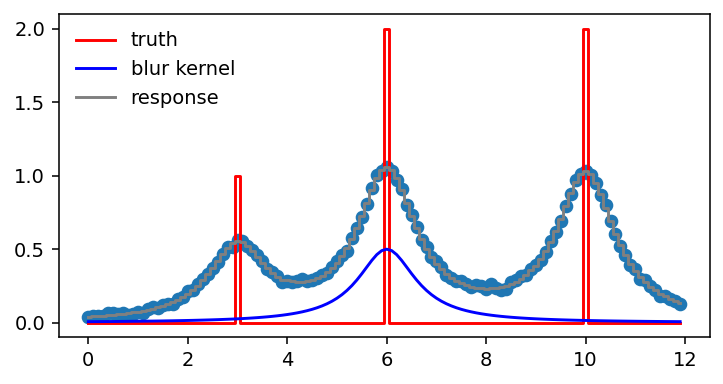

In [7]:
plt.step(DET_AX, SIGNAL, where="mid", label="truth", color="red")
plt.plot(DET_AX, PEAK, label="blur kernel", color="blue")
plt.step(DET_AX, BLURRED, where="mid", label="response", color="gray")
plt.scatter(DET_AX, y)
fig = plt.gcf()
fig.set_size_inches(6, 3)
fig.set_dpi(140)
plt.legend(frameon=False)

In [8]:
print(f"σ^2: {np.nanstd(BLURRED - y) ** 2:.2e}")

σ^2: 9.46e-05


In [9]:
from typing import Iterable


class BlurKernel:
    name: str = "BlurKernel"
    n_parameters_per_basis: int = 1

    def evaluate(self, x: Array, params: Iterable[Array]) -> Array:
        (μ,) = params
        evals = []
        for μi in μ:
            peak = lorentzian(x, μi, 0.5, 1)
            peak /= peak.max()
            evals.append(peak)
        return np.stack(evals)

In [10]:
from numba.experimental.jitclass.decorators import jitclass


class Parameterization:
    def __init__(self, K: int):
        self.K = K
        self.ndim = 2 * K

    def pack(self, structured: tuple[Array, Array, Array]) -> Array:
        I, μ = structured
        θ = np.empty(self.ndim)
        θ[: self.K] = I
        θ[self.K : 2 * self.K] = μ
        # θ[2 * self.K :] = σ
        return θ

    def unpack(self, θ: Array) -> tuple[Array, Array, Array]:
        I: Array = θ[..., : self.K]
        μ: Array = θ[..., self.K : 2 * self.K]
        # σ: Array = θ[..., 2 * self.K :]
        return (I, μ)  # , σ)

    def to_z(self, θ: Array) -> Array:
        z = θ.copy()
        # z[..., : self.K] = np.log(z[..., : self.K])
        return z

    def from_z(self, z: Array) -> Array:
        θ = z.copy()
        # θ[..., : self.K] = np.exp(θ[..., : self.K])
        return θ

    def log_jacobian(self, θ: Array) -> float:
        return 1
        I, μ, σ = self.unpack(θ)
        return float(np.sum(np.log(I)) + np.sum(np.log(θ)))

In [11]:
class LorentzPrior:
    def __init__(self, amplitudes, centers):  # , widths):
        self.amplitudes = amplitudes
        self.centers = centers
        # self.widths = widths

    def sample(self, rng, parameterization) -> Array:
        K: int = parameterization.K
        I: Array = self.amplitudes.sample(rng, K)
        μ: Array = self.centers.sample(rng, K)
        # σ: Array = self.widths.sample(rng, K)
        # print(f"I: {I}, μ: {μ}, σ: {σ}")
        # for Ii, μi, σi in zip(I, μ, σ):
        #     plt.plot(lorentzian(DET_AX, μi, σi, Ii))
        # plt.show()
        return parameterization.pack((I, μ))

    def log_prob(self, θ, parameterization) -> float:
        I, μ = parameterization.unpack(θ)
        lp_I = np.sum(self.amplitudes.log_prob(I))
        lp_μ = np.sum(self.centers.log_prob(μ))
        # lp_σ = np.sum(self.widths.log_prob(σ))
        return float(lp_I + lp_μ)  # + lp_σ)

In [12]:
lorentz_prior = LorentzPrior(
    amplitudes=bsd.UniformPrior(0.2, 1.2),
    centers=bsd.UniformPrior(1, 11),
    # widths=bsd.GammaPrior(5, 8),
)

In [13]:
betas = bsd.beta_schedule(36)

In [14]:
def spectral_model_builder(K: int) -> bsd.SpectralModel:
    return bsd.SpectralModel(
        x=DET_AX,
        y=y,
        basis=BlurKernel(),
        prior=lorentz_prior,
        likelihood=bsd.GaussianNoise(sigma2=1e-4),
        parameterization=Parameterization(K=K),
    )


def sampler_builder(model, rng):
    K = model.parameterization.K
    return bsd.ParallelTempering(
        model=model,
        betas=betas,
        rng=np.random.default_rng(),
        kernel_factory=lambda model, beta, rng: bsd.hmc_kernel_factory(
            model, beta, rng
        ),
    )

In [15]:
runs = bsd.select_model_size(
    model_factory=spectral_model_builder,
    K_values=[2, 3, 4],
    sampler_factory=sampler_builder,
    burn_in=1_000,
    samples=1_000,
    swap_every=10,
    # store_state_trace=True,
)

100%|█████████████████████████████████████████████████████████████████| 1000/1000 [01:26<00:00, 11.60it/s]


K= 2 | stochastic complexity -log Z =  98461599228205734349262178182667793516252019887584316573766093444089493125004408249252042962490008868772380672.000 | beta=1 MH acc=0.810 | mean swap acc=0.689


100%|█████████████████████████████████████████████████████████████████| 1000/1000 [02:26<00:00,  6.81it/s]


K= 3 | stochastic complexity -log Z =  7613561830110250288245375232601097506084707140952751161124008156852233424833954674370502669586214756175314944.000 | beta=1 MH acc=0.816 | mean swap acc=0.631


100%|█████████████████████████████████████████████████████████████████| 1000/1000 [04:09<00:00,  4.01it/s]

K= 4 | stochastic complexity -log Z =  438191778603901961732430497386681269596162209682555851158483518992610736929945432564459196262253688253912711168.000 | beta=1 MH acc=0.826 | mean swap acc=0.602


In [16]:
evidence = [-r.evidence.log_z for r in runs]
best_run = np.argmin(evidence)
K_values = [r.K for r in runs]

optimal_K = K_values[best_run]
print(f"K: {optimal_K}, -logZ: {evidence[best_run]}")

K: 3, -logZ: 7.61356183011025e+108


In [17]:
print(evidence)

[9.846159922820573e+109, 7.61356183011025e+108, 4.3819177860390196e+110]


In [18]:
posteriors = runs[best_run].exchange_result.samples_by_temperature[-1]

μ: 3.004±0.003;
μ: 6.001±0.002;
μ: 10.001±0.002;


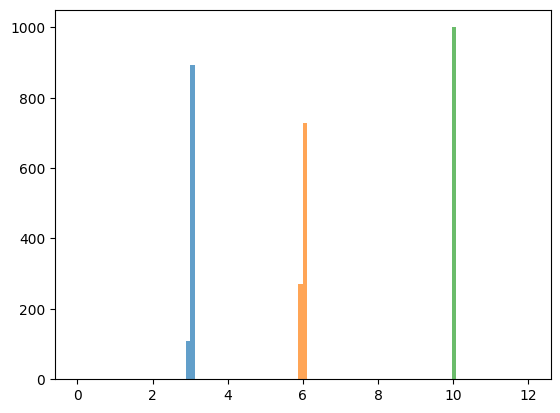

In [19]:
I, μ = Parameterization(K=optimal_K).unpack(
    runs[best_run].exchange_result.samples_by_temperature[-1]
)
key = np.argsort(μ, axis=1)

I = np.take_along_axis(I, axis=1, indices=key)
μ = np.take_along_axis(μ, axis=1, indices=key)
# σ = np.take_along_axis(σ, axis=1, indices=key)

for i in range(optimal_K):
    plt.hist(μ[:, i], range=(0, 12), bins=100, alpha=0.7)
    print(
        f"μ: {np.nanmean(μ[:, i]):.3f}±{np.nanstd(μ[:, i]):.3f};"  # σ: {np.nanmean(σ[:, i]):.3f}±{np.nanstd(σ[:, i]):.2f}"
    )

center: 3.00, height: 0.49
center: 6.00, height: 1.00
center: 10.00, height: 0.99


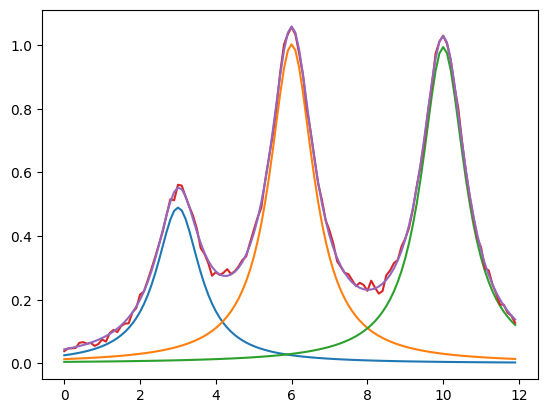

In [20]:
evals = []
for i in range(optimal_K):
    Ii = np.nanmean(I[:, i])
    μi = np.nanmean(μ[:, i])
    # σi = np.nanmean(σ[:, i])
    print(f"center: {μi:.2f}, height: {Ii:.2f}")
    trace = lorentzian(DET_AX, μi, 0.5, 1)
    trace /= trace.max()
    trace *= Ii
    evals.append(trace)
    plt.plot(DET_AX, trace)

plt.plot(DET_AX, y)
plt.plot(DET_AX, np.stack(evals).sum(axis=0))

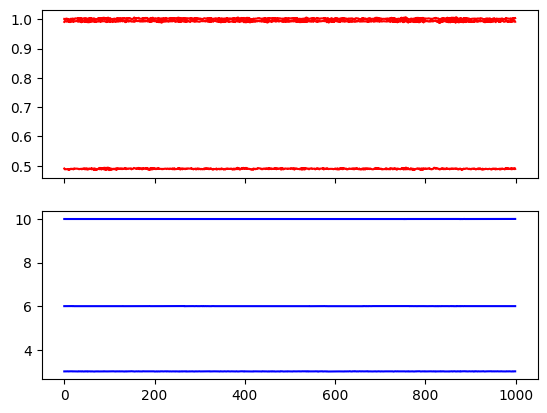

In [21]:
result = runs[best_run].exchange_result
states = result.samples_by_temperature[-1]
I, μ = Parameterization(K=optimal_K).unpack(states)
key = np.argsort(μ, axis=1)

I = np.take_along_axis(I, indices=key, axis=1)
μ = np.take_along_axis(μ, indices=key, axis=1)
# σ = np.take_along_axis(σ, indices=key, axis=1)

fig, (tax, bax) = plt.subplots(nrows=2, sharex=True)

tax.plot(
    I,
    label="amplitudes",
    color="red",
)
bax.plot(
    μ,
    label="centers",
    color="blue",
)

In [22]:
samples = result.samples_by_temperature[-1]

recomputed = np.array(
    [spectral_model_builder(optimal_K).log_likelihood(theta) for theta in samples]
)
stored = np.asarray(result.log_likelihood_trace_by_temperature[-1])

difference = np.max(np.abs(stored - recomputed))
print(difference)

0.0


Text(0.5, 0, '$\\beta_l$')

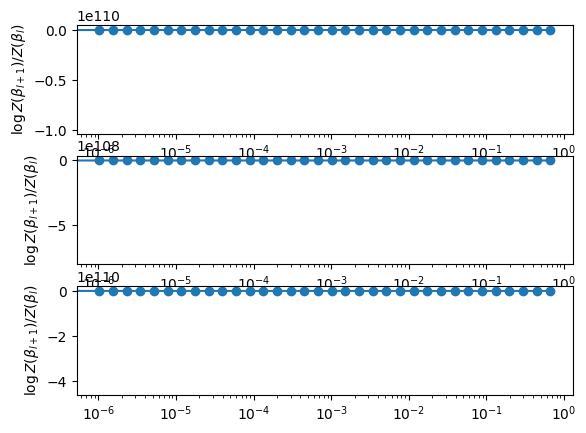

In [23]:
fig, axes = plt.subplots(nrows=3)

for i, run in enumerate(runs):
    res = run.exchange_result

    axes[i].plot(
        res.beta[:-1],
        run.evidence.log_ratios,
        marker="o",
    )
    axes[i].semilogx()
    axes[i].set_ylabel(r"$\log Z(\beta_{l+1})/Z(\beta_l)$")
axes[0].set_xlabel(r"$\beta_l$")

Text(0.5, 0, '$\\beta_l$')

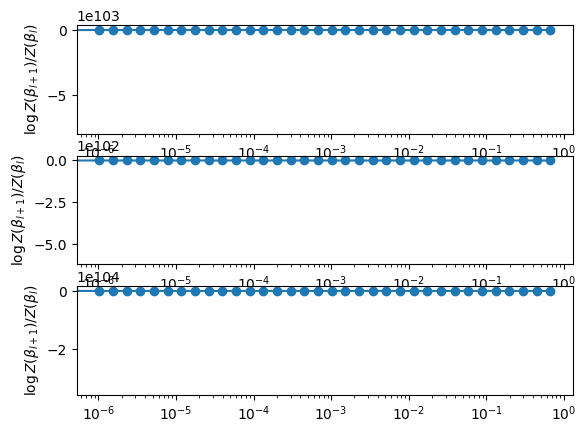

In [24]:
fig, axes = plt.subplots(nrows=3)

for i, run in enumerate(runs):
    res = run.exchange_result

    axes[i].plot(
        res.beta[:-1],
        np.gradient(res.beta)[1:] * run.evidence.log_ratios,
        marker="o",
    )
    axes[i].semilogx()
    axes[i].set_ylabel(r"$\log Z(\beta_{l+1})/Z(\beta_l)$")
axes[0].set_xlabel(r"$\beta_l$")

In [25]:
for l_index in range(result.beta.size - 1):
    delta_beta = result.beta[l_index + 1] - result.beta[l_index]

    log_likelihoods = np.asarray(
        result.log_likelihood_trace_by_temperature[l_index],
        dtype=float,
    )

    log_weights = delta_beta * log_likelihoods

    print(
        f"l: {l_index}, min: {np.min(log_weights):.2f}, max: {np.max(log_weights):.2f}, std: {np.std(log_weights):.2f}"
    )

l: 0, min: -7637877217719675293043049878382561797113718692846226275943980897758652913679897226771820807052535822133755904.00, max: -7613561830110250288245375232601097506084707140952751161124008156852233424833954674370502669586214756175314944.00, std: 4504534339790782638462670110081859747641463945894267184213557320624821836497579163492620193022368351780864.00
l: 1, min: -3.41, max: -0.06, std: 0.50
l: 2, min: -3.11, max: -0.10, std: 0.43
l: 3, min: -3.77, max: -0.13, std: 0.46
l: 4, min: -4.42, max: -0.20, std: 0.58
l: 5, min: -4.18, max: -0.30, std: 0.53
l: 6, min: -3.30, max: -0.44, std: 0.45
l: 7, min: -3.64, max: -0.65, std: 0.45
l: 8, min: -4.31, max: -0.98, std: 0.52
l: 9, min: -5.25, max: -1.47, std: 0.50
l: 10, min: -6.35, max: -2.12, std: 0.55
l: 11, min: -7.07, max: -3.30, std: 0.60
l: 12, min: -9.38, max: -4.93, std: 0.65
l: 13, min: -12.54, max: -7.41, std: 0.63
l: 14, min: -8.73, max: -2.78, std: 0.91
l: 15, min: -11.14, max: -3.89, std: 1.08
l: 16, min: -11.69, max: -5.81,

Text(0, 0.5, '$E_\\beta[\\log L]$')

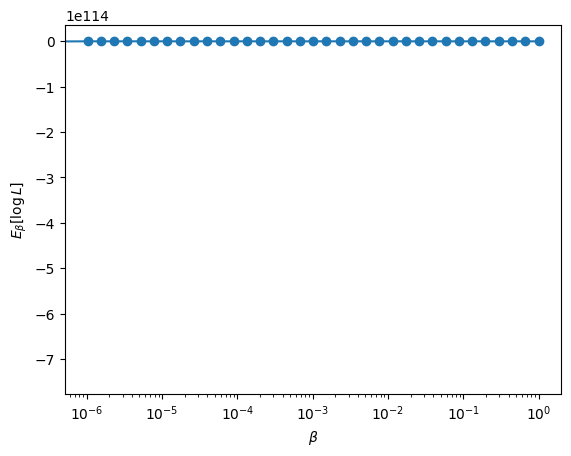

In [26]:
mean_log_likelihood = np.array(
    [np.mean(trace) for trace in result.log_likelihood_trace_by_temperature]
)

plt.plot(result.beta, mean_log_likelihood, marker="o")
plt.semilogx()
plt.xlabel(r"$\beta$")
plt.ylabel(r"$E_\beta[\log L]$")

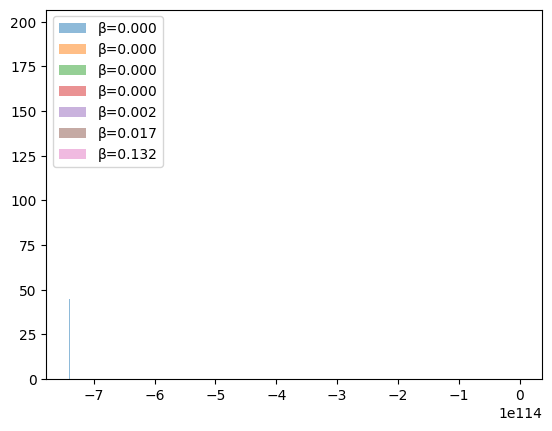

In [27]:
indices = [0, 5, 10, 15, 20, 25, 30]
for i in indices:
    plt.hist(
        result.log_likelihood_trace_by_temperature[i],
        bins=30,
        alpha=0.5,
        label=f"β={result.beta[i]:.3f}",
    )

plt.legend()

Text(0, 0.5, '$\\mathrm{Var}_\\beta(\\log L)$')

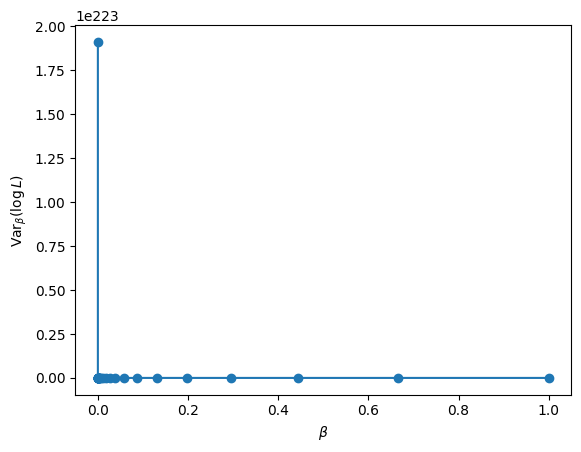

In [28]:
logL_var = np.array(
    [np.var(trace) for trace in result.log_likelihood_trace_by_temperature]
)

plt.plot(result.beta, logL_var, marker="o")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\mathrm{Var}_\beta(\log L)$")